In [1]:
from pathlib import Path
import scanpy as sc
import pandas as pd

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")

adata_path = project_dir / "results/processed/larry_d4_revised_labels_subcluster.h5ad"
adata = sc.read_h5ad(adata_path)

adata

AnnData object with n_obs × n_vars = 4618 × 30428
    obs: 'scrublet_result', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'CellType_man', 'larry_barcode', 'larry_clone', 'CellType_revised_id', 'CellType_revised_full', 'CellType_revised_short', 'CellType_with_endo_sub', 'Endo_subcluster_man', 'CellType_short', 'CellType_short_sub'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_revised_short_colors', 'CellType_short_colors', 'CellType_short_sub_colors', 'CellType_with_endo_sub_colors', 'Tyser_label_colors', 'Tyser_label_v2_colors'

In [2]:
fig_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast/results/figures/302_hemo_larry_rename_plot")
fig_dir.mkdir(parents=True, exist_ok=True)

sc.settings.figdir = str(fig_dir)

In [3]:
source_key = "CellType_revised_short"
new_key = "CellType_short"

rename_map = {
    "ECM ExM": "Adv Mes",
}

assert source_key in adata.obs.columns, f"{source_key} not found in adata.obs"

adata.obs[new_key] = adata.obs[source_key].astype(str).replace(rename_map)

print("Original:")
print(adata.obs[source_key].value_counts())

print("\nNew CellType_short:")
print(adata.obs[new_key].value_counts())

print("\nCheck old labels remaining:")
print(adata.obs[new_key].isin(["ECM ExM"]).value_counts())

Original:
CellType_revised_short
Epi          1453
ECM ExM      1309
HE            494
Trans ExM     440
PGC           269
Nasc Mes      253
Amn           251
Endoderm      149
Name: count, dtype: int64

New CellType_short:
CellType_short
Epi          1453
Adv Mes      1309
HE            494
Trans ExM     440
PGC           269
Nasc Mes      253
Amn           251
Endoderm      149
Name: count, dtype: int64

Check old labels remaining:
CellType_short
False    4618
Name: count, dtype: int64


In [4]:
source_sub_key = "CellType_with_endo_sub"
new_sub_key = "CellType_short_sub"

assert source_sub_key in adata.obs.columns, f"{source_sub_key} not found in adata.obs"

adata.obs[new_sub_key] = adata.obs[source_sub_key].astype(str).replace(rename_map)

print("Original sub:")
print(adata.obs[source_sub_key].value_counts())

print("\nNew CellType_short_sub:")
print(adata.obs[new_sub_key].value_counts())

print("\nCheck old labels remaining in CellType_short_sub:")
print(adata.obs[new_sub_key].isin(["ECM ExM"]).value_counts())

Original sub:
CellType_with_endo_sub
Epi           1453
ECM ExM       1309
HE             494
Trans ExM      440
PGC            269
Nasc Mes       253
Amn            251
CDX2+ Hypo      65
Late Hypo       45
Early Hypo      39
Name: count, dtype: int64

New CellType_short_sub:
CellType_short_sub
Epi           1453
Adv Mes       1309
HE             494
Trans ExM      440
PGC            269
Nasc Mes       253
Amn            251
CDX2+ Hypo      65
Late Hypo       45
Early Hypo      39
Name: count, dtype: int64

Check old labels remaining in CellType_short_sub:
CellType_short_sub
False    4618
Name: count, dtype: int64


In [5]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=100,
    dpi_save=600,
    facecolor="white",
    frameon=False,
    vector_friendly=True,
)

In [29]:
celltype_palette = {
    # epithelial / embryo
    "Epi": "#8C6BB1",
    "Epi trans": "#F1A340",
    "PS": "#E377C2",
    "Ambig.": "#7F7F7F",
    "Amn": "#AEC7E8",
    "TE": "#FDB462",
    "PGC": "#006400",

    # endoderm / hypoblast
    "Endoderm": "#999999",
    "Early Hypo": "#CC79A7",
    "Late Hypo": "#0072B2",
    "CDX2+ Hypo": "#E69F00",

    # mesoderm / ExM
    "Nasc Mes": "#BCBD22",
    "Emerg Mes": "#C49C94",
    "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    "YS Mes": "#FF9896",

    # endothelial
    "HE": "#D55E00",
    "Art": "#66C2A5",
    "Vein": "#3288BD",

    # blood / erythroid / myeloid
    "Blood/Ery": "#D62728",
    "Ery": "#D62728",
    "EMP": "#FDBF6F",
    "Mk": "#984EA3",
    "Gran": "#F0E442",
}


In [7]:
def set_alphabetical_categories_and_colors(adata, key, palette):
    observed = sorted(adata.obs[key].astype(str).unique())

    missing_from_palette = sorted(set(observed) - set(palette))
    if missing_from_palette:
        raise ValueError(f"{key}: labels missing from palette: {missing_from_palette}")

    adata.obs[key] = pd.Categorical(
        adata.obs[key].astype(str),
        categories=observed,
        ordered=False,
    )

    adata.uns[f"{key}_colors"] = [palette[x] for x in observed]

    print(f"\n{key} alphabetical categories:")
    print(observed)

    return pd.DataFrame({
        key: observed,
        "color": adata.uns[f"{key}_colors"],
    })

In [8]:
import pandas as pd

def apply_alphabetical_palette(adata, key, palette):
    labels = sorted(adata.obs[key].astype(str).unique())

    missing = sorted(set(labels) - set(palette))
    if missing:
        raise ValueError(f"{key}: missing colors for {missing}")

    adata.obs[key] = pd.Categorical(
        adata.obs[key].astype(str),
        categories=labels,
        ordered=False,
    )

    adata.uns[f"{key}_colors"] = [palette[x] for x in labels]

    return pd.DataFrame({
        key: labels,
        "color": adata.uns[f"{key}_colors"],
    })

In [9]:
df_colors = apply_alphabetical_palette(
    adata,
    key="CellType_short",
    palette=celltype_palette,
)

df_colors

,CellType_short,color
0,Adv Mes,#8C564B
1,Amn,#AEC7E8
2,Endoderm,#999999
3,Epi,#8C6BB1
4,HE,#D55E00
5,Nasc Mes,#BCBD22
6,PGC,#006400
7,Trans ExM,#17BECF


In [12]:
df_colors = apply_alphabetical_palette(
    adata,
    key="CellType_short_sub",
    palette=celltype_palette,
)

df_colors

,CellType_short_sub,color
0,Adv Mes,#8C564B
1,Amn,#AEC7E8
2,CDX2+ Hypo,#E69F00
3,Early Hypo,#CC79A7
4,Epi,#8C6BB1
5,HE,#D55E00
6,Late Hypo,#0072B2
7,Nasc Mes,#BCBD22
8,PGC,#006400
9,Trans ExM,#17BECF


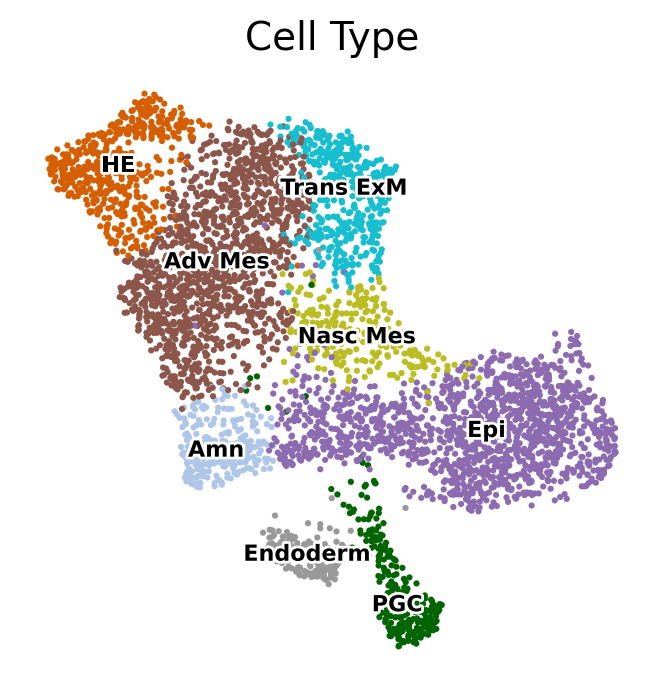

In [10]:
sc.pl.umap(adata, color='CellType_short', 
           frameon=False, legend_loc='on data', 
           legend_fontsize=8, legend_fontoutline=2, title='Cell Type', size=20,
           save='_d4_basic_annotations.pdf')

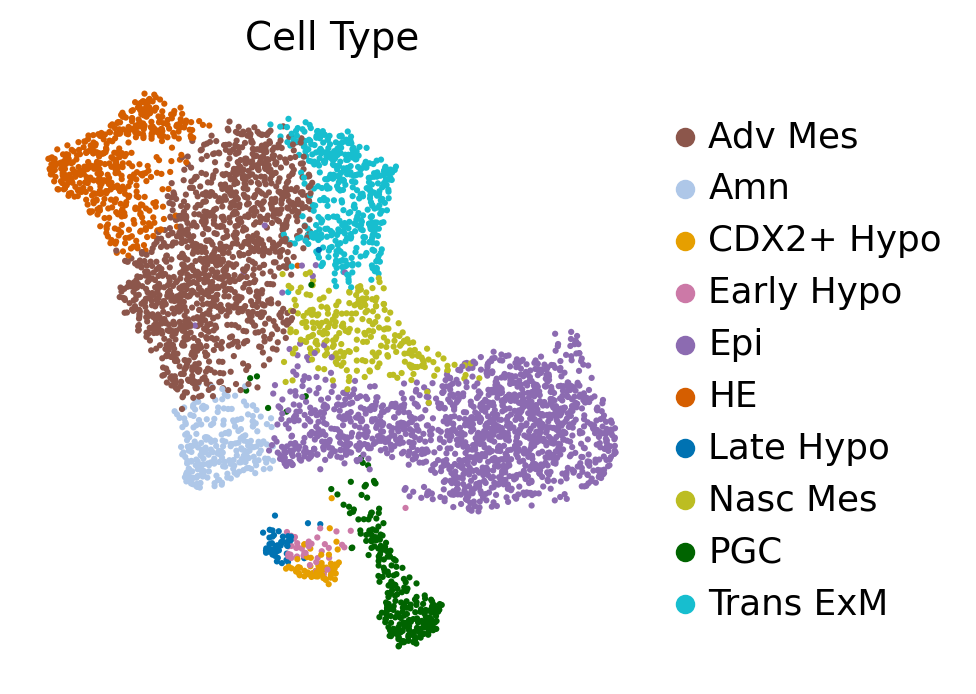

In [13]:
sc.pl.umap(adata, color='CellType_short_sub', 
           frameon=False, 
        #    legend_loc='right', legend_fontsize=8, legend_fontoutline=2, 
           title='Cell Type', size=20,
           save='_d4_sub_annotations_legend_side.pdf')

In [14]:
adata_endo = adata[adata.obs['CellType_short'].isin(['Endoderm'])]

In [15]:
if "counts" in adata_endo.layers:
    adata_endo.X = adata_endo.layers["counts"].copy()

# Basic filtering safeguards: keep genes detected in at least a few Endo cells
sc.pp.filter_genes(adata_endo, min_cells=3)

sc.pp.normalize_total(adata_endo, target_sum=1e4)
sc.pp.log1p(adata_endo)

sc.pp.highly_variable_genes(
    adata_endo,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
)

# Keep all genes in object for plotting; PCA uses HVGs by default if present
sc.pp.scale(adata_endo, max_value=10)
sc.tl.pca(adata_endo, svd_solver="arpack")
sc.pp.neighbors(adata_endo, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_endo, random_state=0)
sc.tl.leiden(adata_endo, resolution=0.5, random_state=0, key_added="endo_leiden")

print(adata_endo.obs["endo_leiden"].value_counts().sort_index())

filtered out 12319 genes that are detected in less than 3 cells


/mnt/yiming/nfs_share/anaconda3/envs/hypoblast/lib/python3.10/site-packages/anndata/_core/anndata.py:602: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/tmp/ipykernel_1274566/201557419.py:2: UserWarning: Trying to set a dense array with a sparse array on a view.Densifying the sparse array.This may incur excessive memory usage
  adata_endo.X = adata_endo.layers["counts"].copy()
/tmp/ipykernel_1274566/201557419.py:2: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_endo.X = adata_endo.layers["counts"].copy()
/mnt/yiming/nfs_share/anaconda3/envs/hypoblast/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Try

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:11)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)
running Leiden clustering
    finished: found 3 clusters and added
    'endo_leiden', the cluster labels (adata.obs, categorical) (0:00:00)
endo_leiden
0    65
1    45
2    39
Name: count, dtype: int64


/tmp/ipykernel_1274566/201557419.py:22: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_endo, resolution=0.5, random_state=0, key_added="endo_leiden")


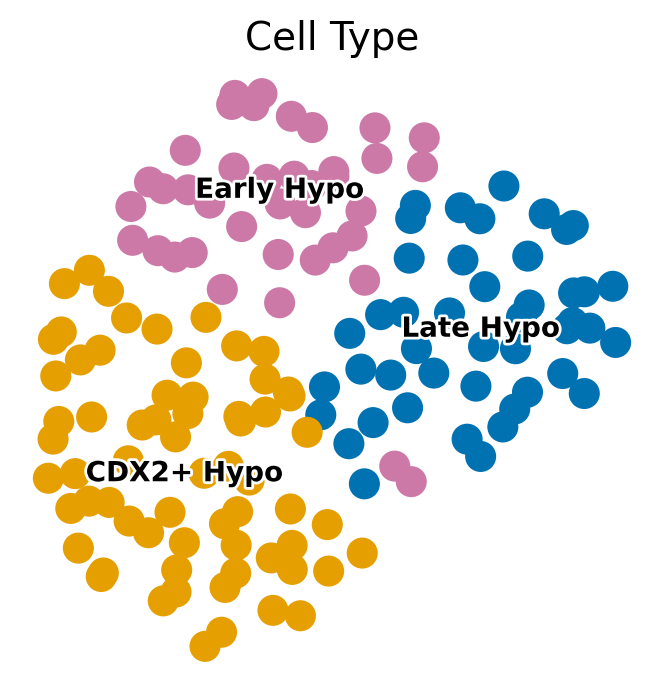

In [16]:
sc.pl.umap(adata_endo, color='CellType_short_sub', 
           frameon=False, 
           legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, 
           title='Cell Type', size=500,
           save='_d4_sub_only_annotations_legend_on.pdf')

In [17]:
adata.write_h5ad(
    "/mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d4_revised_labels_subcluster.h5ad"
)

In [18]:
project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")

adata_path = project_dir / "results/processed/larry_d7_revised_labels.h5ad"
adata = sc.read_h5ad(adata_path)

In [19]:
source_key = "CellType_revised_short"
new_key = "CellType_short"

rename_map = {
    "YS ExM": "YS Mes",
    "ECM ExM": "Adv Mes", 
    "Emerg.Mes": "Emerg Mes",
    "Endo": "Endoderm"
    
}

assert source_key in adata.obs.columns, f"{source_key} not found in adata.obs"

adata.obs[new_key] = adata.obs[source_key].astype(str).replace(rename_map)

print("Original:")
print(adata.obs[source_key].value_counts())

print("\nNew CellType_short:")
print(adata.obs[new_key].value_counts())

print("\nCheck old labels remaining:")
print(adata.obs[new_key].isin(["ECM ExM"]).value_counts())

Original:
CellType_revised_short
ECM ExM      1600
Amn           655
Trans ExM     519
HE            382
EMP           284
Epi           109
PS             87
PGC            70
Endo           46
Ery            40
Emerg.Mes      32
Name: count, dtype: int64

New CellType_short:
CellType_short
Adv Mes      1600
Amn           655
Trans ExM     519
HE            382
EMP           284
Epi           109
PS             87
PGC            70
Endoderm       46
Ery            40
Emerg Mes      32
Name: count, dtype: int64

Check old labels remaining:
CellType_short
False    3824
Name: count, dtype: int64


In [20]:
df_colors = apply_alphabetical_palette(
    adata,
    key="CellType_short",
    palette=celltype_palette,
)

df_colors

,CellType_short,color
0,Adv Mes,#8C564B
1,Amn,#AEC7E8
2,EMP,#FDBF6F
3,Emerg Mes,#C49C94
4,Endoderm,#999999
5,Epi,#8C6BB1
6,Ery,#D62728
7,HE,#D55E00
8,PGC,#006400
9,PS,#E377C2


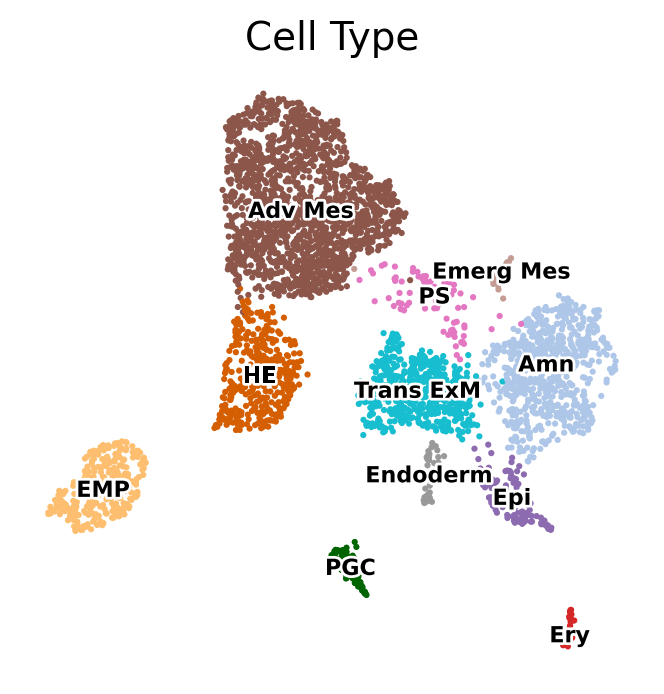

In [21]:
sc.pl.umap(adata, color='CellType_short', 
           frameon=False, legend_loc='on data', 
           legend_fontsize=8, legend_fontoutline=2, title='Cell Type', size=20,
           save='_d7_basic_annotations.pdf')

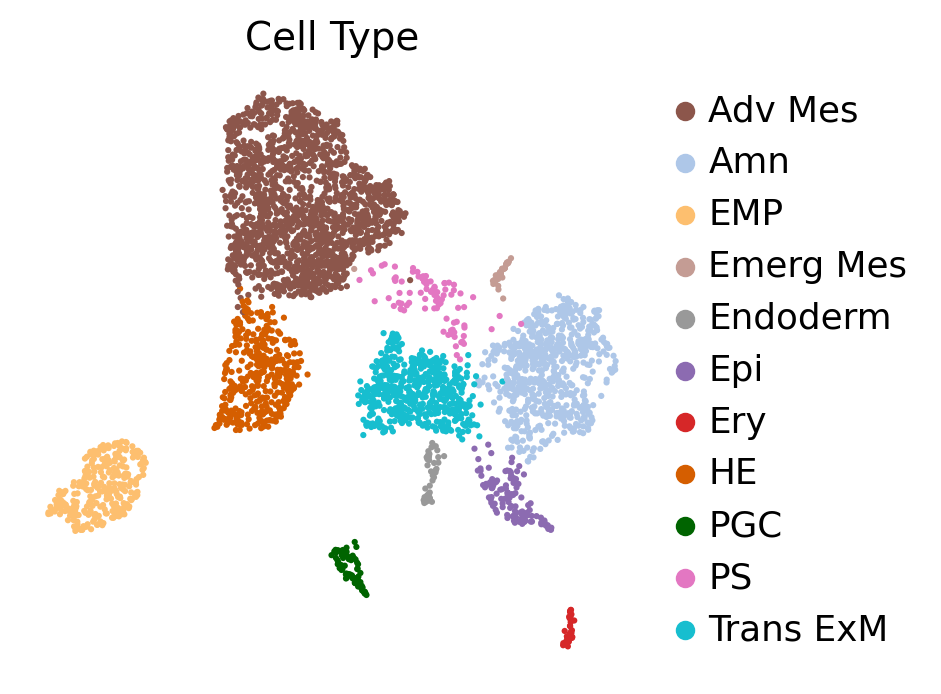

In [22]:
sc.pl.umap(adata, color='CellType_short', 
           frameon=False, 
        #    legend_loc='right', legend_fontsize=8, legend_fontoutline=2, 
           title='Cell Type', size=20,
           save='_d7_basic_annotations_legend_side.pdf')

In [23]:
adata.write_h5ad(
    "/mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d7_revised_labels.h5ad"
)

In [24]:
project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")

adata_path = project_dir / "results/processed/larry_d12_revised_labels.h5ad"
adata = sc.read_h5ad(adata_path)

In [25]:
source_key = "CellType_revised_short"
new_key = "CellType_short"

rename_map = {
    "YS ExM": "YS Mes",
    "ECM ExM": "Adv Mes", 
    "Emerg.Mes": "Emerg Mes"
    
}

assert source_key in adata.obs.columns, f"{source_key} not found in adata.obs"

adata.obs[new_key] = adata.obs[source_key].astype(str).replace(rename_map)

print("Original:")
print(adata.obs[source_key].value_counts())

print("\nNew CellType_short:")
print(adata.obs[new_key].value_counts())

print("\nCheck old labels remaining:")
print(adata.obs[new_key].isin(["ECM ExM"]).value_counts())

Original:
CellType_revised_short
Ery        2689
ECM ExM    2303
Amn        1393
Mk         1289
YS ExM      614
EMP         430
Vein        126
Art          76
PGC          57
Gran         33
Name: count, dtype: int64

New CellType_short:
CellType_short
Ery        2689
Adv Mes    2303
Amn        1393
Mk         1289
YS Mes      614
EMP         430
Vein        126
Art          76
PGC          57
Gran         33
Name: count, dtype: int64

Check old labels remaining:
CellType_short
False    9010
Name: count, dtype: int64


In [30]:
df_colors = apply_alphabetical_palette(
    adata,
    key="CellType_short",
    palette=celltype_palette,
)

df_colors

,CellType_short,color
0,Adv Mes,#8C564B
1,Amn,#AEC7E8
2,Art,#66C2A5
3,EMP,#FDBF6F
4,Ery,#D62728
5,Gran,#F0E442
6,Mk,#984EA3
7,PGC,#006400
8,Vein,#3288BD
9,YS Mes,#FF9896


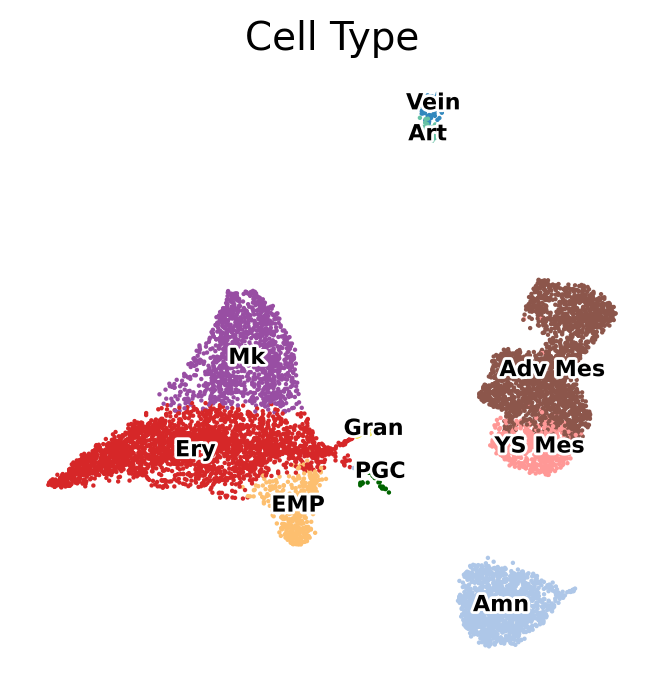

In [31]:
sc.pl.umap(adata, color='CellType_short', 
           frameon=False, legend_loc='on data', 
           legend_fontsize=8, legend_fontoutline=2, title='Cell Type', size=10,
           save='_d12_basic_annotations.pdf')

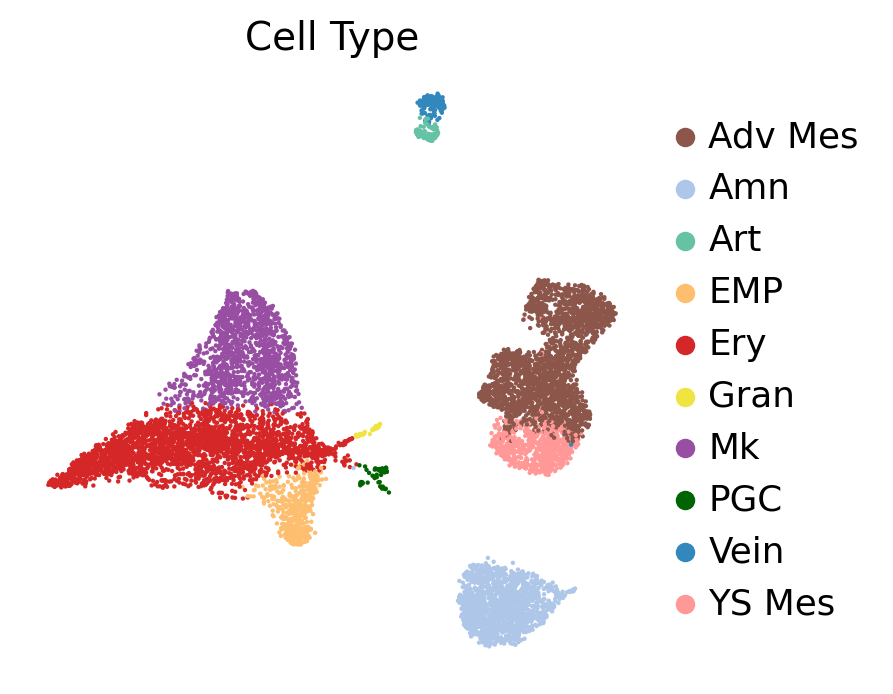

In [32]:
sc.pl.umap(adata, color='CellType_short', 
           frameon=False, 
        #    legend_loc='right', legend_fontsize=8, legend_fontoutline=2, 
           title='Cell Type', size=10,
           save='_d12_basic_annotations_legend_side.pdf')

In [33]:
adata.write_h5ad(
    "/mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d12_revised_labels.h5ad"
)